To Do:
New implementations to add (on top of your MP1 Mandelbrot code):
▶ Multiprocessing — Pool.map with row-chunk parallelism (this session)
▶ Dask — local cluster (L05–L06)
▶ Dask — AAU Strato HPC cluster (L07)
What to hand in (same structure as MP1):
▶ Code: .py or .ipynb file(s)
▶ Performance notebook: timing table + speedup plot for all implementations
▶ Git log: git log --format="%ad %h %s" --date=short --stat > git log.txt
▶ Reflection: 150+ words typed in the Moodle text field
⇒ Start documenting your Mandelbrot parallel results today — your performance notebook entries count toward MP2.

M1

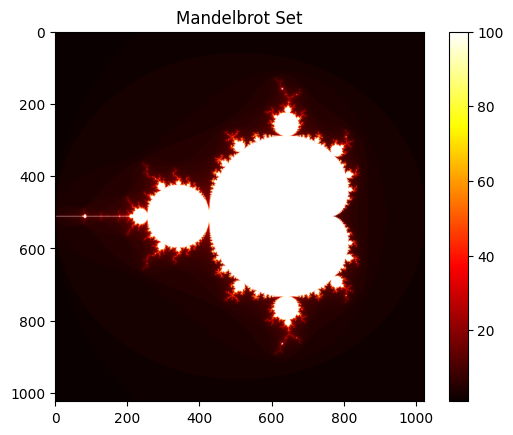

In [4]:
import numpy as np
from numba import njit
from multiprocessing import Pool
import time, os, statistics, matplotlib.pyplot as plt
from pathlib import Path

@njit
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0:
            return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col * dx, c_imag, max_iter)
    return out

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter=100):
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

plt.imshow(mandelbrot_serial(1024, -2, 1, -1.5, 1.5, max_iter=100), cmap="hot")
plt.title("Mandelbrot Set")
plt.colorbar()
plt.savefig("mandelbrot.png")
plt.show()